<a href="https://colab.research.google.com/github/FardinLakdawala/eda-assignment-25AI1021/blob/main/PCA_Housing_Step_by_Step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA Step-by-Step on the Housing Dataset (13-D → 1-D)
### Mean, variance, standard deviation, correlation, covariance matrix, eigenvalues, eigenvectors, projection

This notebook repeats the same 9-step PCA pipeline from the 2-D worked example, now on the **housing dataset (506 samples, 13 features + price)**.

| # | Step | # | Step |
|---|------|---|------|
| 1 | Original data | 6 | Find eigenvectors |
| 2 | Mean, variance, std, correlation | 7 | Data with principal components |
| 3 | Center (and scale) the data | 8 | Project onto PC1 |
| 4 | Compute covariance matrix | 9 | High-D → 1-D representation |
| 5 | Find eigenvalues | | |

**How to run in Google Colab:** run the cells top to bottom. When the *Load data* cell asks, upload `housing.csv`
(or drag it into the Files panel on the left first). All graphs are drawn inside the notebook.

**Two adjustments compared with the 2-D example**
1. With 13 features on very different scales (e.g. `TAX` ≈ 400 vs `NOX` ≈ 0.5), plain covariance-PCA would just rediscover the biggest-scale feature. So Step 3 also **scales every feature to unit variance** (z-scores). The covariance matrix of standardized data *is* the correlation matrix. You can switch this off with `STANDARDIZE = False`, and a comparison at the end shows what changes.
2. PCA is unsupervised, so the price column `MEDV` is **not** used to build the components. It is only used to colour the plots afterwards.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA               # only used at the end to cross-check the manual results
from sklearn.preprocessing import StandardScaler    # only used at the end to cross-check the manual results

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True, linewidth=140)
pd.options.display.float_format = "{:.4f}".format
pd.options.display.max_columns = 30

BLUE, ORANGE, RED, GREEN, PURPLE = "#2b5fb4", "#e07b00", "#d62728", "#2ca02c", "#7b3fb4"

# ------------------------- settings you can change -------------------------
STANDARDIZE = True        # True  → centre AND scale (correlation-matrix PCA, recommended)
                          # False → centre only (covariance-matrix PCA, as in the 2-D example)
FEATURES_TO_DROP = []     # e.g. ["B"] to leave features out of the PCA (see the note on `B` below)
TARGET = "MEDV"           # price column: NOT used by PCA, only used to colour plots

## Step 1 — Original Data

`housing.csv` has no header row (values are whitespace-separated), so column names are assigned here. The values match the classic Boston Housing dataset:

| Column | Meaning | Column | Meaning |
|---|---|---|---|
| CRIM | per-capita crime rate | DIS | distance to employment centres |
| ZN | share of large residential lots | RAD | accessibility to radial highways |
| INDUS | share of non-retail business land | TAX | property-tax rate |
| CHAS | borders Charles River (0/1) | PTRATIO | pupil–teacher ratio |
| NOX | nitric-oxide concentration | B | index derived from the proportion of Black residents in the town* |
| RM | average rooms per dwelling | LSTAT | % lower-status population |
| AGE | share of homes built before 1940 | **MEDV** | median home value in $1000s (target, not used by PCA) |

\* `B` is a controversial variable (scikit-learn removed this dataset from its library partly because of it). It is kept here so the analysis uses the file as given; put `"B"` in `FEATURES_TO_DROP` above to exclude it. `CHAS` is binary and is used as-is.

In [ ]:
CSV_PATH = "housing.csv"
if not os.path.exists(CSV_PATH):
    try:                                    # Google Colab: show an upload button
        from google.colab import files
        print("Please upload housing.csv ...")
        uploaded = files.upload()
        CSV_PATH = next(iter(uploaded))
    except ImportError:
        raise FileNotFoundError("housing.csv not found - put it in the same folder as this notebook.")

col_names = ["CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE", "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"]
df = pd.read_csv(CSV_PATH, sep=r"\s+", header=None, names=col_names)
assert df.shape[1] == len(col_names), "Unexpected number of columns in the file"

print(f"Rows: {df.shape[0]},  Columns: {df.shape[1]},  Missing values: {int(df.isna().sum().sum())}")
display(df.head(10))

Rows: 506,  Columns: 14,  Missing values: 0


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.0063,18.0000,2.3100,0,0.5380,6.5750,65.2000,4.0900,1,296.0000,15.3000,396.9000,4.9800,24.0000
1,0.0273,0.0000,7.0700,0,0.4690,6.4210,78.9000,4.9671,2,242.0000,17.8000,396.9000,9.1400,21.6000
2,0.0273,0.0000,7.0700,0,0.4690,7.1850,61.1000,4.9671,2,242.0000,17.8000,392.8300,4.0300,34.7000
3,0.0324,0.0000,2.1800,0,0.4580,6.9980,45.8000,6.0622,3,222.0000,18.7000,394.6300,2.9400,33.4000
4,0.0691,0.0000,2.1800,0,0.4580,7.1470,54.2000,6.0622,3,222.0000,18.7000,396.9000,5.3300,36.2000
5,0.0299,0.0000,2.1800,0,0.4580,6.4300,58.7000,6.0622,3,222.0000,18.7000,394.1200,5.2100,28.7000
6,0.0883,12.5000,7.8700,0,0.5240,6.0120,66.6000,5.5605,5,311.0000,15.2000,395.6000,12.4300,22.9000
7,0.1446,12.5000,7.8700,0,0.5240,6.1720,96.1000,5.9505,5,311.0000,15.2000,396.9000,19.1500,27.1000
8,0.2112,12.5000,7.8700,0,0.5240,5.6310,100.0000,6.0821,5,311.0000,15.2000,386.6300,29.9300,16.5000
9,0.1700,12.5000,7.8700,0,0.5240,6.0040,85.9000,6.5921,5,311.0000,15.2000,386.7100,17.1000,18.9000


n = 506 samples, p = 13 features used for PCA:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


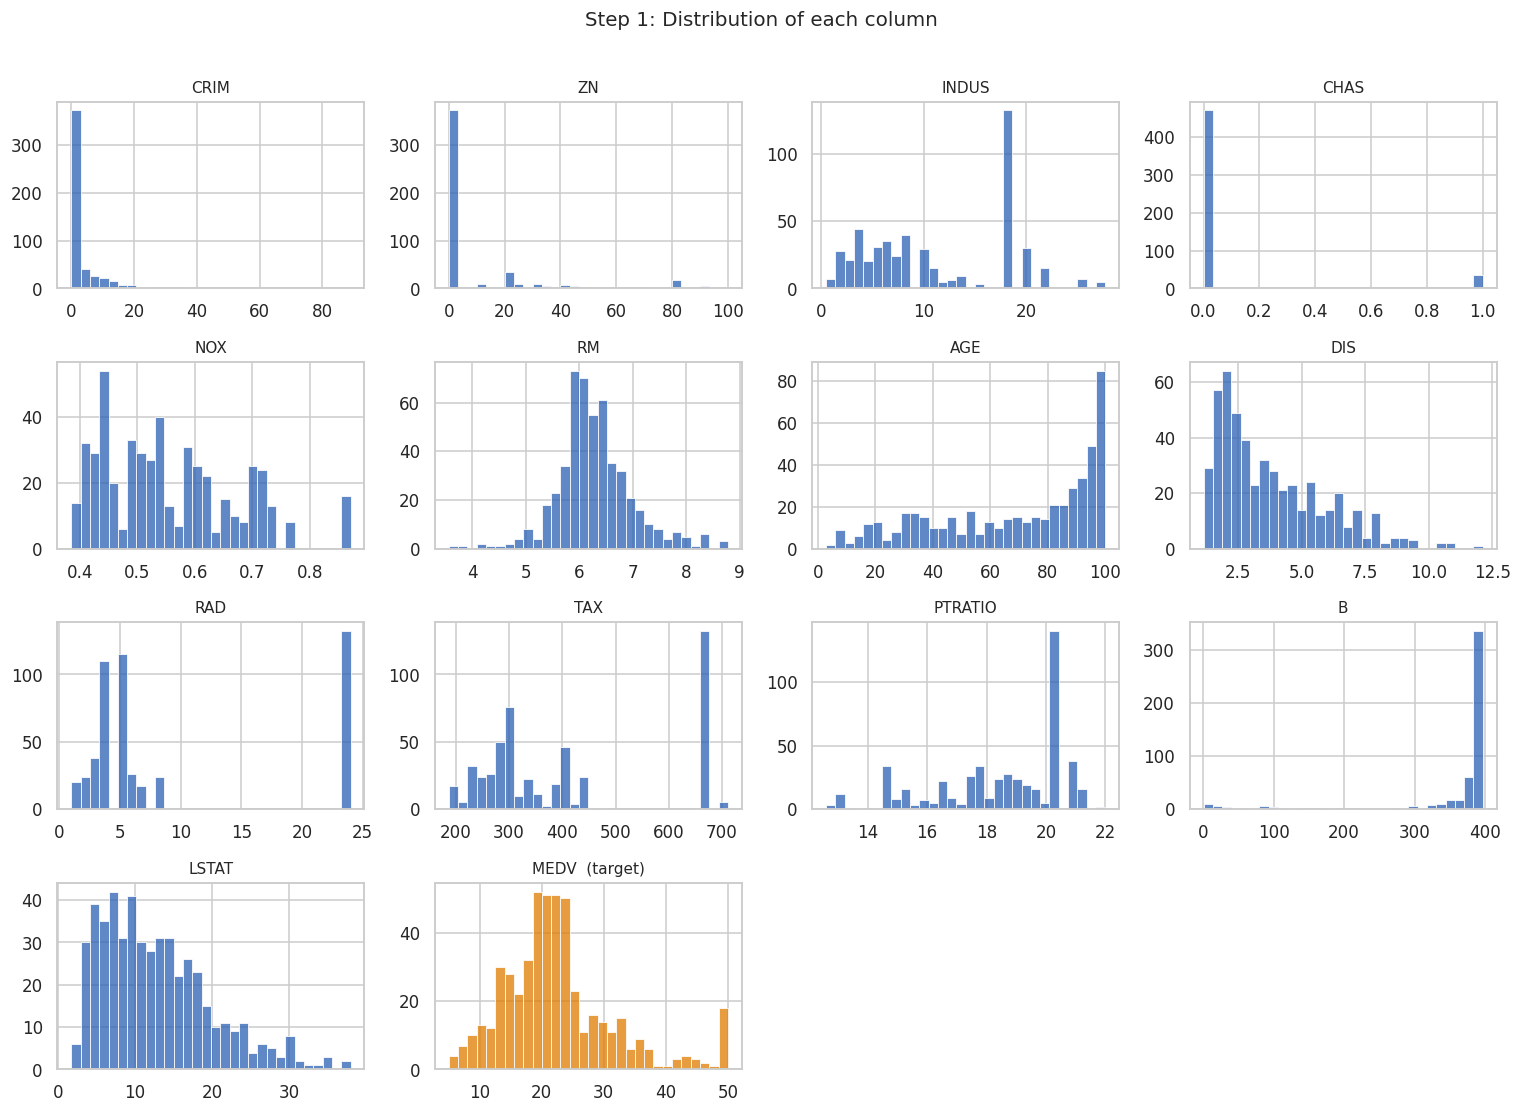

In [ ]:
feature_cols = [c for c in df.columns if c != TARGET and c not in FEATURES_TO_DROP]
X = df[feature_cols].to_numpy(dtype=float)      # data matrix, shape (n, p)
y_target = df[TARGET].to_numpy(dtype=float)     # only for colouring plots
n, p = X.shape
print(f"n = {n} samples, p = {p} features used for PCA:\n{feature_cols}")

# distribution of every column
fig, axes = plt.subplots(4, 4, figsize=(14, 10))
for ax, c in zip(axes.ravel(), df.columns):
    sns.histplot(df[c], bins=30, color=BLUE if c != TARGET else ORANGE, ax=ax)
    ax.set_title(c + ("  (target)" if c == TARGET else ""), fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
for ax in axes.ravel()[len(df.columns):]:
    ax.axis("off")
fig.suptitle("Step 1: Distribution of each column", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Step 2 — Mean, Variance, Standard Deviation and Correlation

$$\bar{x}_j = \frac{1}{n}\sum_{i=1}^{n} x_{ij} \qquad
\text{Var}(x_j) = \frac{1}{n}\sum_{i}(x_{ij}-\bar{x}_j)^2 \qquad
\sigma_j = \sqrt{\text{Var}(x_j)} \qquad
r_{jk} = \frac{\text{Cov}(x_j,x_k)}{\sigma_j\,\sigma_k}$$

As in the 2-D example, variances use the population formula (÷ n); the sample version (÷ n−1) is shown too.

Mean vector μ:


,mean
CRIM,3.6135
ZN,11.3636
INDUS,11.1368
CHAS,0.0692
NOX,0.5547
RM,6.2846
AGE,68.5749
DIS,3.7950
RAD,9.5494
TAX,408.2372


,Mean,Median,Min,Max,Variance (population ÷n),Variance (sample ÷n−1),Std Dev (population ÷n),Std Dev (sample ÷n−1)
CRIM,3.6135,0.2565,0.0063,88.9762,73.8404,73.9866,8.5930,8.6015
ZN,11.3636,0.0000,0.0000,100.0000,542.8618,543.9368,23.2994,23.3225
INDUS,11.1368,9.6900,0.4600,27.7400,46.9714,47.0644,6.8536,6.8604
CHAS,0.0692,0.0000,0.0000,1.0000,0.0644,0.0645,0.2537,0.2540
NOX,0.5547,0.5380,0.3850,0.8710,0.0134,0.0134,0.1158,0.1159
RM,6.2846,6.2085,3.5610,8.7800,0.4927,0.4937,0.7019,0.7026
AGE,68.5749,77.5000,2.9000,100.0000,790.7925,792.3584,28.1210,28.1489
DIS,3.7950,3.2074,1.1296,12.1265,4.4253,4.4340,2.1036,2.1057
RAD,9.5494,5.0000,1.0000,24.0000,75.6665,75.8164,8.6987,8.7073
TAX,408.2372,330.0000,187.0000,711.0000,28348.6236,28404.7595,168.3705,168.5371


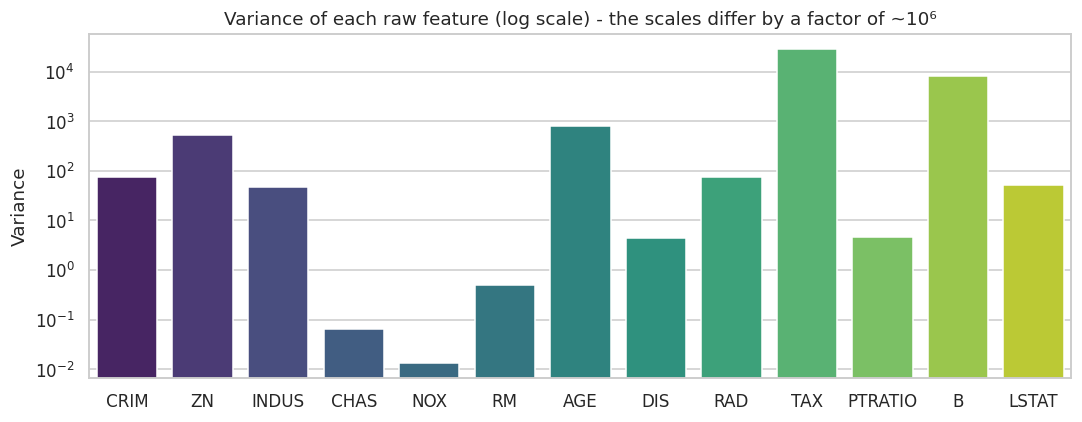

In [ ]:
feat_df = df[feature_cols]

mean_vec = feat_df.mean()
print("Mean vector μ:")
display(mean_vec.to_frame("mean"))

stats = pd.DataFrame({
    "Mean":                     feat_df.mean(),
    "Median":                   feat_df.median(),
    "Min":                      feat_df.min(),
    "Max":                      feat_df.max(),
    "Variance (population ÷n)": feat_df.var(ddof=0),
    "Variance (sample ÷n−1)":   feat_df.var(ddof=1),
    "Std Dev (population ÷n)":  feat_df.std(ddof=0),
    "Std Dev (sample ÷n−1)":    feat_df.std(ddof=1),
})
display(stats)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=stats.index, y=stats["Variance (population ÷n)"], hue=stats.index,
            palette="viridis", legend=False, ax=ax)
ax.set_yscale("log")
ax.set(title="Variance of each raw feature (log scale) - the scales differ by a factor of ~10⁶",
       ylabel="Variance", xlabel="")
plt.tight_layout()
plt.show()

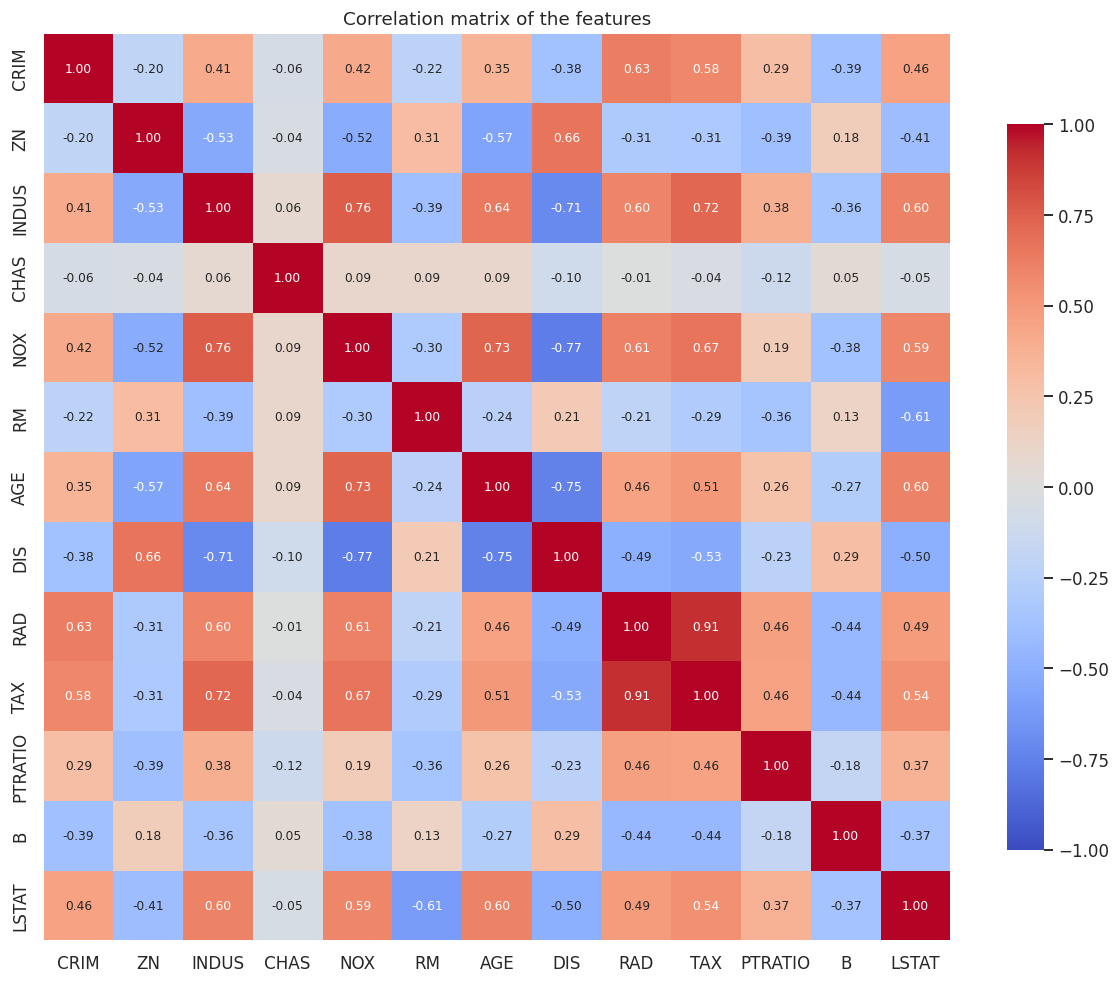

Most strongly correlated feature pairs:


,feature 1,feature 2,r,|r|
0,RAD,TAX,0.9102,0.9102
1,NOX,DIS,-0.7692,0.7692
2,INDUS,NOX,0.7637,0.7637
3,AGE,DIS,-0.7479,0.7479
4,NOX,AGE,0.7315,0.7315
5,INDUS,TAX,0.7208,0.7208
6,INDUS,DIS,-0.7080,0.7080
7,NOX,TAX,0.6680,0.6680



Manual check for (RAD, TAX):  Cov = 1333.1167,  r = 0.9102   (pandas: 0.9102)


In [ ]:
# Pearson correlation matrix
corr = feat_df.corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True,
            annot_kws={"size": 8}, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation matrix of the features")
plt.tight_layout()
plt.show()

# strongest pairs
iu = np.triu_indices(p, k=1)
names = np.array(feature_cols)
pairs = pd.DataFrame({"feature 1": names[iu[0]], "feature 2": names[iu[1]], "r": corr.to_numpy()[iu]})
pairs["|r|"] = pairs["r"].abs()
pairs = pairs.sort_values("|r|", ascending=False).reset_index(drop=True)
print("Most strongly correlated feature pairs:")
display(pairs.head(8))

# manual check of the formula r = Cov / (σx σy) for the strongest pair
a, b = pairs.loc[0, "feature 1"], pairs.loc[0, "feature 2"]
cov_ab = np.mean((df[a] - df[a].mean()) * (df[b] - df[b].mean()))
r_manual = cov_ab / (df[a].std(ddof=0) * df[b].std(ddof=0))
print(f"\nManual check for ({a}, {b}):  Cov = {cov_ab:.4f},  r = {r_manual:.4f}   (pandas: {corr.loc[a, b]:.4f})")
assert np.isclose(r_manual, corr.loc[a, b])

## Step 3 — Center (and Scale) the Data

**Centering** (same as the 2-D example) moves the cloud of points onto the origin:

$$X_c = X - \mu$$

**Scaling** (extra step for multi-scale features) divides each column by its standard deviation, giving z-scores:

$$Z = \frac{X - \mu}{\sigma}$$

After this, every feature has mean 0 and variance 1, so no feature dominates just because of its units.

Data used for PCA: standardized (z-scores)

Centred data  Xc = X − μ  (first 5 rows):


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-3.6072,6.6364,-8.8268,-0.0692,-0.0167,0.2904,-3.3749,0.2950,-8.5494,-112.2372,-3.1555,40.2260,-7.6731
1,-3.5862,-11.3636,-4.0668,-0.0692,-0.0857,0.1364,10.3251,1.1721,-7.5494,-166.2372,-0.6555,40.2260,-3.5131
2,-3.5862,-11.3636,-4.0668,-0.0692,-0.0857,0.9004,-7.4749,1.1721,-7.5494,-166.2372,-0.6555,36.1560,-8.6231
3,-3.5812,-11.3636,-8.9568,-0.0692,-0.0967,0.7134,-22.7749,2.2672,-6.5494,-186.2372,0.2445,37.9560,-9.7131
4,-3.5445,-11.3636,-8.9568,-0.0692,-0.0967,0.8624,-14.3749,2.2672,-6.5494,-186.2372,0.2445,40.2260,-7.3231


Standardized data  Z = (X − μ) / σ  (first 5 rows):


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.4198,0.2848,-1.2879,-0.2726,-0.1442,0.4137,-0.1200,0.1402,-0.9828,-0.6666,-1.4590,0.4411,-1.0756
1,-0.4173,-0.4877,-0.5934,-0.2726,-0.7403,0.1943,0.3672,0.5572,-0.8679,-0.9873,-0.3031,0.4411,-0.4924
2,-0.4173,-0.4877,-0.5934,-0.2726,-0.7403,1.2827,-0.2658,0.5572,-0.8679,-0.9873,-0.3031,0.3964,-1.2087
3,-0.4168,-0.4877,-1.3069,-0.2726,-0.8353,1.0163,-0.8099,1.0777,-0.7529,-1.1061,0.1130,0.4162,-1.3615
4,-0.4125,-0.4877,-1.3069,-0.2726,-0.8353,1.2286,-0.5112,1.0777,-0.7529,-1.1061,0.1130,0.4411,-1.0265


Check - means should be ≈ 0, std should be 1:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
mean of Z,-0.0000,0.0000,0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,-0.0000,-0.0000,-0.0000
std of Z,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000


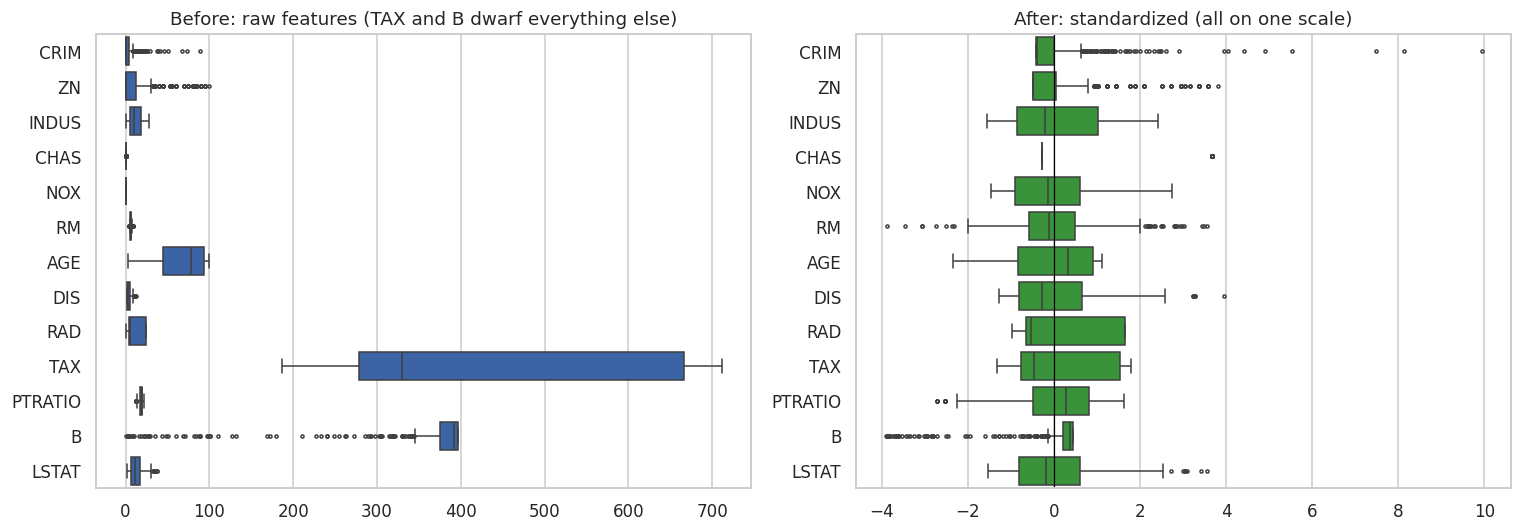

In [ ]:
mu = X.mean(axis=0)
sigma = X.std(axis=0, ddof=0)

Xc = X - mu                                   # centred data
Z = Xc / sigma if STANDARDIZE else Xc.copy()  # data actually used for PCA
print(f"Data used for PCA: {'standardized (z-scores)' if STANDARDIZE else 'centred only'}\n")

print("Centred data  Xc = X − μ  (first 5 rows):")
display(pd.DataFrame(Xc, columns=feature_cols).head())
if STANDARDIZE:
    print("Standardized data  Z = (X − μ) / σ  (first 5 rows):")
    display(pd.DataFrame(Z, columns=feature_cols).head())

check = pd.DataFrame({"mean of Z": Z.mean(axis=0), "std of Z": Z.std(axis=0)}, index=feature_cols).T
print("Check - means should be ≈ 0" + (", std should be 1:" if STANDARDIZE else ":"))
display(check)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=pd.DataFrame(X, columns=feature_cols), orient="h", color=BLUE, fliersize=2, ax=axes[0])
axes[0].set_title("Before: raw features (TAX and B dwarf everything else)")
sns.boxplot(data=pd.DataFrame(Z, columns=feature_cols), orient="h", color=GREEN, fliersize=2, ax=axes[1])
axes[1].set_title("After: " + ("standardized (all on one scale)" if STANDARDIZE else "centred only"))
axes[1].axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

## Step 4 — Compute the Covariance Matrix

$$C = \frac{1}{n}\,Z^{T}Z \qquad (p \times p,\ \text{symmetric})$$

The diagonal holds the variances and the off-diagonal entries hold the covariances. For standardized data, $C$ is exactly the correlation matrix.

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
CRIM,1.0000,-0.2005,0.4066,-0.0559,0.4210,-0.2192,0.3527,-0.3797,0.6255,0.5828,0.2899,-0.3851,0.4556
ZN,-0.2005,1.0000,-0.5338,-0.0427,-0.5166,0.3120,-0.5695,0.6644,-0.3119,-0.3146,-0.3917,0.1755,-0.4130
INDUS,0.4066,-0.5338,1.0000,0.0629,0.7637,-0.3917,0.6448,-0.7080,0.5951,0.7208,0.3832,-0.3570,0.6038
CHAS,-0.0559,-0.0427,0.0629,1.0000,0.0912,0.0913,0.0865,-0.0992,-0.0074,-0.0356,-0.1215,0.0488,-0.0539
NOX,0.4210,-0.5166,0.7637,0.0912,1.0000,-0.3022,0.7315,-0.7692,0.6114,0.6680,0.1889,-0.3801,0.5909
RM,-0.2192,0.3120,-0.3917,0.0913,-0.3022,1.0000,-0.2403,0.2052,-0.2098,-0.2920,-0.3555,0.1281,-0.6138
AGE,0.3527,-0.5695,0.6448,0.0865,0.7315,-0.2403,1.0000,-0.7479,0.4560,0.5065,0.2615,-0.2735,0.6023
DIS,-0.3797,0.6644,-0.7080,-0.0992,-0.7692,0.2052,-0.7479,1.0000,-0.4946,-0.5344,-0.2325,0.2915,-0.4970
RAD,0.6255,-0.3119,0.5951,-0.0074,0.6114,-0.2098,0.4560,-0.4946,1.0000,0.9102,0.4647,-0.4444,0.4887
TAX,0.5828,-0.3146,0.7208,-0.0356,0.6680,-0.2920,0.5065,-0.5344,0.9102,1.0000,0.4609,-0.4418,0.5440


✔ Covariance matrix of the standardized data equals the correlation matrix.
Diagonal (variances):  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Symmetric: True


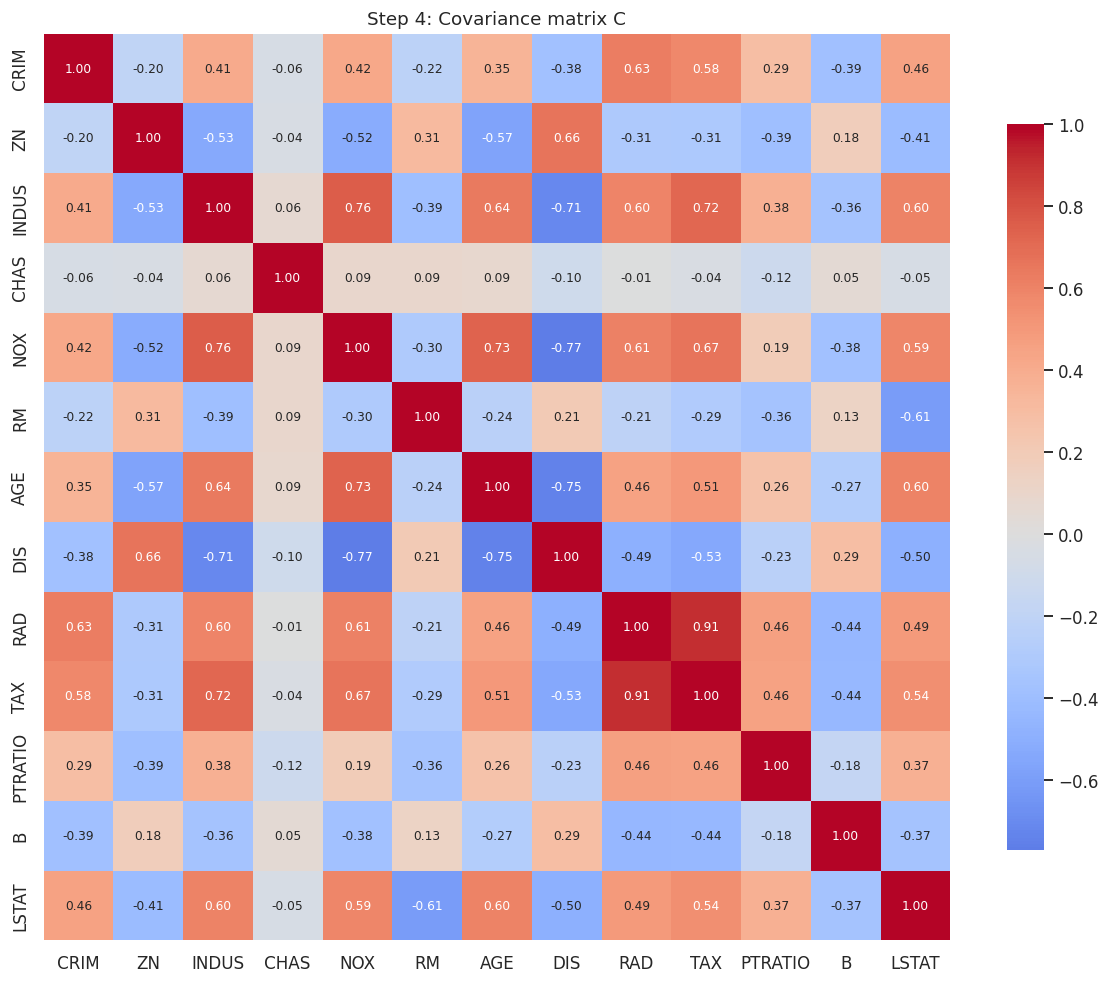

In [ ]:
C = (Z.T @ Z) / n
C_df = pd.DataFrame(C, index=feature_cols, columns=feature_cols)
display(C_df)

assert np.allclose(C, np.cov(Z.T, bias=True))          # matches NumPy
if STANDARDIZE:
    assert np.allclose(C, np.corrcoef(X.T))            # covariance of z-scores = correlation matrix
    print("✔ Covariance matrix of the standardized data equals the correlation matrix.")
print(f"Diagonal (variances):  {np.round(np.diag(C), 4)}")
print(f"Symmetric: {np.allclose(C, C.T)}")

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(C_df, annot=True, fmt=".2f", cmap="Blues" if not STANDARDIZE else "coolwarm",
            center=0 if STANDARDIZE else None, square=True, annot_kws={"size": 8},
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Step 4: Covariance matrix C")
plt.tight_layout()
plt.show()

## Step 5 — Find Eigenvalues

Solve the characteristic equation

$$\det(C - \lambda I) = 0$$

For a 2×2 matrix this is a quadratic; for a 13×13 matrix it is a degree-13 polynomial, so we solve it numerically with `np.linalg.eigh` (built for symmetric matrices).
Each eigenvalue is the variance of the data along one principal direction, and

$$\text{explained variance of PC}_k = \frac{\lambda_k}{\sum_j \lambda_j}$$

Σ λ = 13.0000   trace(C) = 13.0000
Π λ = 0.000132855   det(C)   = 0.000132855


,Eigenvalue,Explained variance (%),Cumulative (%)
PC1,6.1268,47.1296,47.1296
PC2,1.4333,11.0252,58.1548
PC3,1.2426,9.5586,67.7134
PC4,0.8576,6.5967,74.3101
PC5,0.8348,6.4217,80.7318
PC6,0.6574,5.0570,85.7888
PC7,0.5354,4.1181,89.9069
PC8,0.3961,3.0469,92.9538
PC9,0.2769,2.1303,95.0841
PC10,0.2202,1.6941,96.7783



λ₁ = 6.1268 → PC1 explains 47.13% of the variance
λ₂ = 1.4333 → PC2 explains 11.03%  (PC1 + PC2 = 58.15%)
Components to keep: Kaiser rule → 3,  80% variance → 5,  90% variance → 8


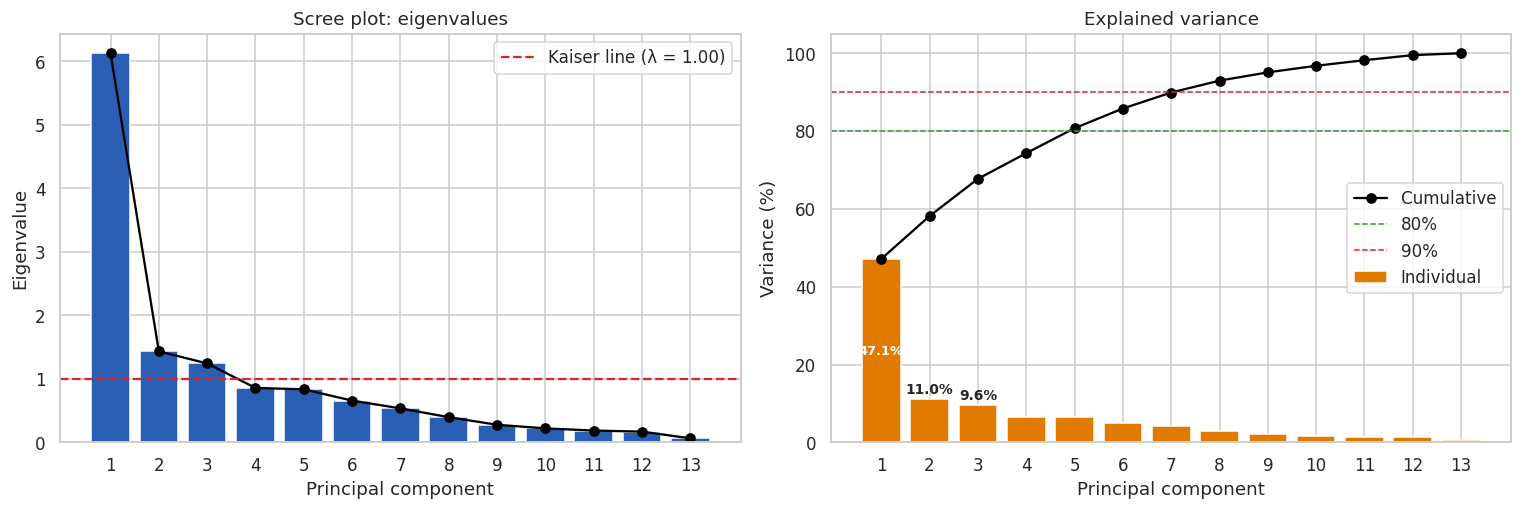

In [ ]:
eigvals, eigvecs = np.linalg.eigh(C)
order = np.argsort(eigvals)[::-1]                 # largest first
eigvals, eigvecs = eigvals[order], eigvecs[:, order]

pc_names = [f"PC{i}" for i in range(1, p + 1)]
explained = eigvals / eigvals.sum()
cum_explained = np.cumsum(explained)

# Theory checks: Σλ = trace(C), Πλ = det(C), and a general-purpose solver agrees
print(f"Σ λ = {eigvals.sum():.4f}   trace(C) = {np.trace(C):.4f}")
print(f"Π λ = {np.prod(eigvals):.6g}   det(C)   = {np.linalg.det(C):.6g}")
assert np.allclose(np.sort(np.linalg.eigvals(C).real)[::-1], eigvals)

ev_table = pd.DataFrame({
    "Eigenvalue": eigvals,
    "Explained variance (%)": explained * 100,
    "Cumulative (%)": cum_explained * 100,
}, index=pc_names)
display(ev_table)

# how many components to keep?
k_kaiser = int((eigvals > eigvals.mean()).sum())            # Kaiser rule: λ > average λ (=1 for standardized data)
k80 = int(np.searchsorted(cum_explained, 0.80) + 1)
k90 = int(np.searchsorted(cum_explained, 0.90) + 1)
print(f"\nλ₁ = {eigvals[0]:.4f} → PC1 explains {explained[0]*100:.2f}% of the variance")
print(f"λ₂ = {eigvals[1]:.4f} → PC2 explains {explained[1]*100:.2f}%  (PC1 + PC2 = {cum_explained[1]*100:.2f}%)")
print(f"Components to keep: Kaiser rule → {k_kaiser},  80% variance → {k80},  90% variance → {k90}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].bar(range(1, p + 1), eigvals, color=BLUE)
axes[0].plot(range(1, p + 1), eigvals, "o-", color="black")
axes[0].axhline(eigvals.mean(), color=RED, ls="--", label=f"Kaiser line (λ = {eigvals.mean():.2f})")
axes[0].set(title="Scree plot: eigenvalues", xlabel="Principal component", ylabel="Eigenvalue", xticks=range(1, p + 1))
axes[0].legend()

axes[1].bar(range(1, p + 1), explained * 100, color=ORANGE, label="Individual")
axes[1].plot(range(1, p + 1), cum_explained * 100, "o-", color="black", label="Cumulative")
axes[1].axhline(80, color=GREEN, ls="--", lw=1, label="80%")
axes[1].axhline(90, color=RED, ls="--", lw=1, label="90%")
for i in range(min(3, p)):
    if i == 0:   # PC1: label inside the bar (its cumulative dot sits on top of the bar)
        axes[1].text(1, explained[0] * 100 / 2, f"{explained[0]*100:.1f}%", ha="center", va="center",
                     fontsize=8.5, fontweight="bold", color="white")
    else:        # other PCs: label above the bar
        axes[1].text(i + 1, explained[i] * 100 + 1.5, f"{explained[i]*100:.1f}%", ha="center", fontsize=9, fontweight="bold")
axes[1].set(title="Explained variance", xlabel="Principal component", ylabel="Variance (%)",
            xticks=range(1, p + 1), ylim=(0, 105))
axes[1].legend(loc="center right")
plt.tight_layout()
plt.show()

## Step 6 — Find Eigenvectors

For each eigenvalue solve $(C - \lambda I)\,v = 0$ and normalise $\lVert v\rVert = 1$. The entries of $v_k$ are the **loadings**: how much each original feature contributes to $\text{PC}_k$.
The sign of an eigenvector is arbitrary; we choose the sign so that the largest-magnitude loading is positive.

In [ ]:
# sign convention: largest |loading| positive
for j in range(p):
    if eigvecs[np.argmax(np.abs(eigvecs[:, j])), j] < 0:
        eigvecs[:, j] *= -1

loadings = pd.DataFrame(eigvecs, index=feature_cols, columns=pc_names)
print("Eigenvector matrix V (columns = eigenvectors / loadings):")
display(loadings)

# Manual solve of (C − λ₁ I) v = 0: the null-space vector is the last right-singular vector
_, _, vt = np.linalg.svd(C - eigvals[0] * np.eye(p))
v1_manual = vt[-1]
assert np.allclose(np.abs(v1_manual), np.abs(eigvecs[:, 0]))
print("✔ Solving (C − λ₁I)v = 0 by SVD gives the same v₁ (up to sign).")

# Checks
assert np.allclose(C @ eigvecs, eigvecs * eigvals)          # C v = λ v for every pair
assert np.allclose(eigvecs.T @ eigvecs, np.eye(p))          # orthonormal
off_diag = eigvecs.T @ eigvecs - np.eye(p)
print(f"✔ C·v = λ·v holds for all {p} pairs.")
print(f"✔ Eigenvectors are orthonormal: max |vᵢ·vⱼ| for i≠j = {np.abs(off_diag).max():.2e},  norms = {np.linalg.norm(eigvecs, axis=0).round(4)[:3]} …")

for j in range(2):
    col = pc_names[j]
    top = loadings[col].abs().sort_values(ascending=False).head(4).index
    print(f"{col} is driven mainly by: " + ", ".join(f"{f} ({loadings.loc[f, col]:+.2f})" for f in top))

Eigenvector matrix V (columns = eigenvectors / loadings):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
CRIM,0.2510,-0.3153,0.2466,0.0618,-0.0822,0.2197,0.7776,-0.1534,0.2604,-0.0194,0.1096,0.0868,0.0460
ZN,-0.2563,-0.3233,0.2959,0.1287,-0.3206,0.3234,-0.2750,0.4027,0.3581,-0.2675,-0.2628,-0.0714,-0.0809
INDUS,0.3467,0.1125,-0.0159,0.0171,0.0078,0.0761,-0.3396,-0.1739,0.6444,0.3635,0.3032,-0.1132,-0.2511
CHAS,0.0050,0.4548,0.2898,0.8159,-0.0865,-0.1675,0.0741,0.0247,-0.0137,0.0062,-0.0139,-0.0040,0.0359
NOX,0.3429,0.2191,0.1210,-0.1282,-0.1369,0.1530,-0.1996,-0.0801,-0.0185,-0.2311,-0.1113,0.8043,0.0436
RM,-0.1892,0.1493,0.5940,-0.2806,0.4234,-0.0593,0.0639,0.3268,0.0479,0.4314,-0.0532,0.1529,0.0456
AGE,0.3137,0.3120,-0.0177,-0.1752,-0.0167,0.0717,0.1160,0.6008,-0.0676,-0.3628,0.4592,-0.2119,-0.0386
DIS,-0.3215,-0.3491,-0.0497,0.2154,-0.0986,-0.0234,-0.1039,0.1218,-0.1533,0.1712,0.6957,0.3909,-0.0183
RAD,0.3198,-0.2715,0.2873,0.1323,0.2041,0.1432,-0.1379,-0.0804,-0.4709,-0.0219,-0.0365,-0.1070,-0.6335
TAX,0.3385,-0.2395,0.2207,0.1033,0.1305,0.1929,-0.3149,-0.0828,-0.1766,0.0352,0.1048,-0.2152,0.7202


✔ Solving (C − λ₁I)v = 0 by SVD gives the same v₁ (up to sign).
✔ C·v = λ·v holds for all 13 pairs.
✔ Eigenvectors are orthonormal: max |vᵢ·vⱼ| for i≠j = 2.22e-15,  norms = [1. 1. 1.] …
PC1 is driven mainly by: INDUS (+0.35), NOX (+0.34), TAX (+0.34), DIS (-0.32)
PC2 is driven mainly by: CHAS (+0.45), DIS (-0.35), ZN (-0.32), CRIM (-0.32)


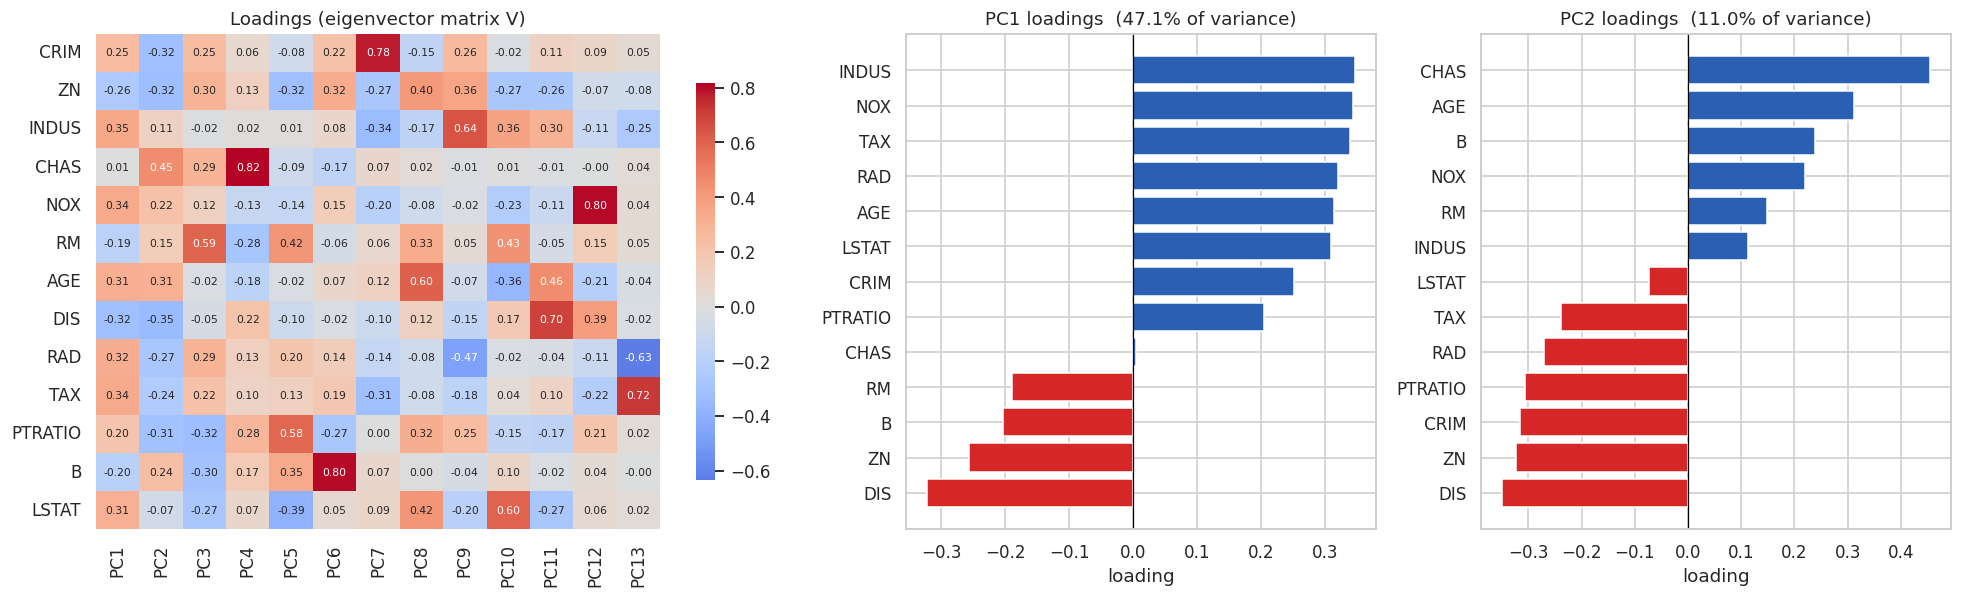

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.6), gridspec_kw={"width_ratios": [1.5, 1, 1]})

sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, annot_kws={"size": 7},
            cbar_kws={"shrink": 0.8}, ax=axes[0])
axes[0].set_title("Loadings (eigenvector matrix V)")

for ax, col in zip(axes[1:], ["PC1", "PC2"]):
    s = loadings[col].sort_values()
    ax.barh(s.index, s.values, color=[RED if v < 0 else BLUE for v in s.values])
    ax.axvline(0, color="black", lw=0.8)
    ax.set(title=f"{col} loadings  ({explained[int(col[2:]) - 1]*100:.1f}% of variance)", xlabel="loading")
plt.tight_layout()
plt.show()

## Step 7 — Data with Principal Components

Every house now gets new coordinates along the principal axes (its *scores*). Plotting PC1 against PC2 shows the data in the plane that keeps the most variance.
The right-hand panel is a **biplot**: arrows show how each original feature points in this PC1–PC2 plane.

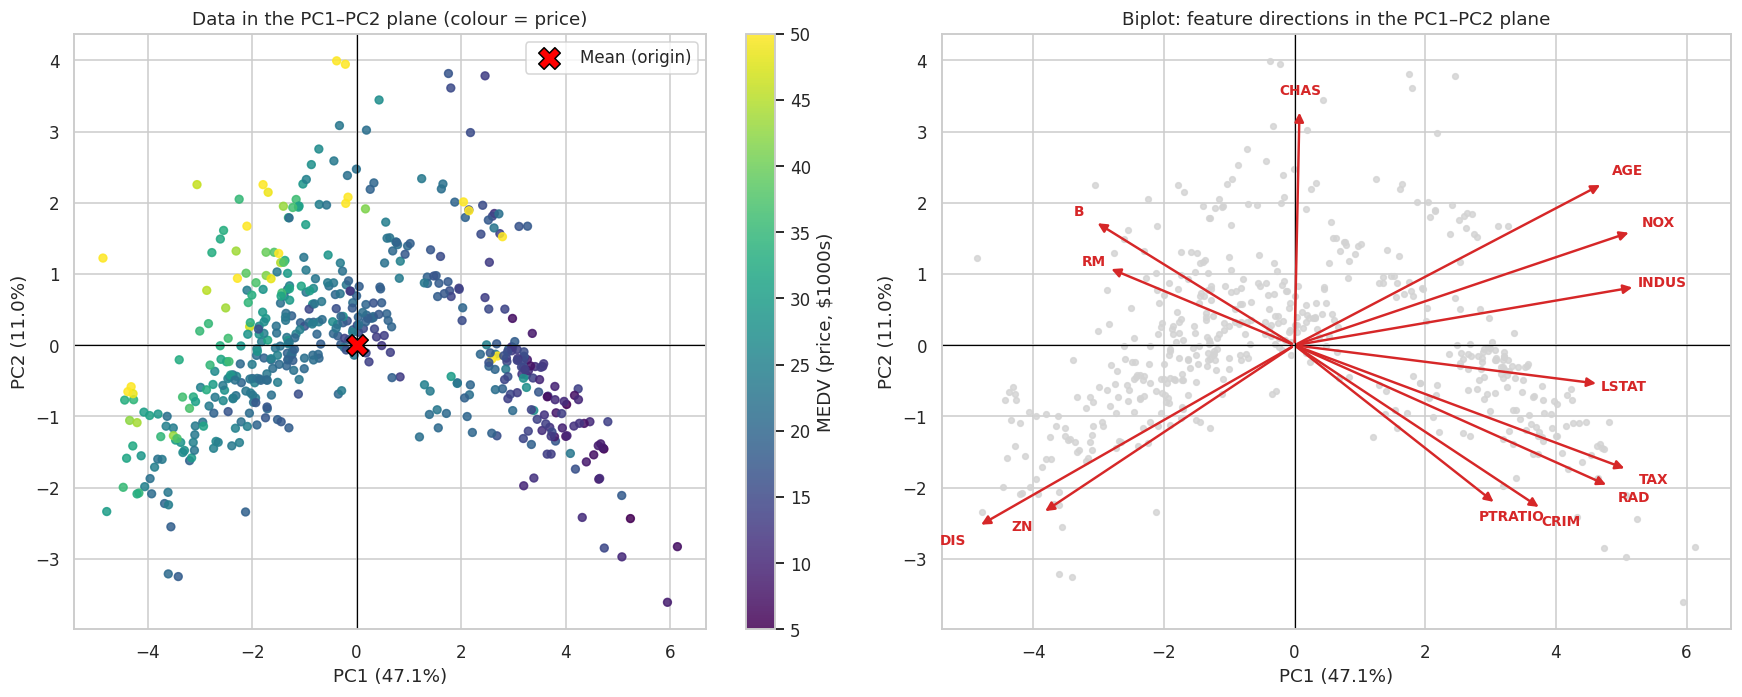

In [ ]:
scores = Z @ eigvecs                  # all PC scores, shape (n, p)  (Step 8 explains the projection in detail)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# left: scores coloured by price
sc = axes[0].scatter(scores[:, 0], scores[:, 1], c=y_target, cmap="viridis", s=26, alpha=0.85)
axes[0].axhline(0, color="black", lw=0.8); axes[0].axvline(0, color="black", lw=0.8)
axes[0].scatter(0, 0, marker="X", s=200, color="red", edgecolor="black", zorder=5, label="Mean (origin)")
cb = fig.colorbar(sc, ax=axes[0]); cb.set_label(f"{TARGET} (price, $1000s)")
axes[0].set(xlabel=f"PC1 ({explained[0]*100:.1f}%)", ylabel=f"PC2 ({explained[1]*100:.1f}%)",
            title="Data in the PC1–PC2 plane (colour = price)")
axes[0].legend(loc="upper right")

# right: biplot
L = eigvecs[:, :2] * np.sqrt(eigvals[:2])                      # loadings scaled by √λ
arrow_scale = 0.85 * np.abs(scores[:, :2]).max() / np.abs(L).max()
axes[1].scatter(scores[:, 0], scores[:, 1], s=14, color="lightgray", alpha=0.8)
for name, (lx, ly) in zip(feature_cols, L * arrow_scale):
    axes[1].annotate("", xy=(lx, ly), xytext=(0, 0), arrowprops=dict(arrowstyle="-|>", color=RED, lw=1.6))
    axes[1].text(lx * 1.08, ly * 1.08, name, color=RED, fontsize=9, ha="center", va="center", fontweight="bold")
axes[1].axhline(0, color="black", lw=0.8); axes[1].axvline(0, color="black", lw=0.8)
axes[1].set(xlabel=f"PC1 ({explained[0]*100:.1f}%)", ylabel=f"PC2 ({explained[1]*100:.1f}%)",
            title="Biplot: feature directions in the PC1–PC2 plane")
plt.tight_layout()
plt.show()

## Step 8 — Project the Data onto PC1

For each sample the PC1 score is the dot product of its (centred / standardized) row with $v_1$:

$$z_i = Z_i \cdot v_1 = \sum_{j=1}^{p} v_{1j}\, z_{ij}$$

In [ ]:
v1 = eigvecs[:, 0]
z = Z @ v1                                   # PC1 projection of all samples

# worked example for sample 1
terms = pd.DataFrame({"v₁ (loading)": v1, "z_1j (sample 1)": Z[0], "product": v1 * Z[0]}, index=feature_cols)
display(terms)
print(f"z₁ = Σ products = {terms['product'].sum():.4f}     (matches Z @ v₁ → {z[0]:.4f})\n")

# projection table (first 10 samples)
proj_table = pd.DataFrame(Z, columns=feature_cols)
proj_table["PC1 projection (z)"] = z
proj_table.index = np.arange(1, n + 1); proj_table.index.name = "Sample"
display(proj_table.head(10))

# full score matrix checks
assert np.allclose(scores.var(axis=0), eigvals)
sc_corr = np.corrcoef(scores.T)
print(f"✔ Variance of each PC score equals its eigenvalue:  {scores.var(axis=0)[:4]} …")
print(f"✔ PC scores are uncorrelated: max |corr| between different PCs = {np.abs(sc_corr - np.eye(p)).max():.2e}")

,v₁ (loading),z_1j (sample 1),product
CRIM,0.2510,-0.4198,-0.1053
ZN,-0.2563,0.2848,-0.0730
INDUS,0.3467,-1.2879,-0.4465
CHAS,0.0050,-0.2726,-0.0014
NOX,0.3429,-0.1442,-0.0494
RM,-0.1892,0.4137,-0.0783
AGE,0.3137,-0.1200,-0.0376
DIS,-0.3215,0.1402,-0.0451
RAD,0.3198,-0.9828,-0.3143
TAX,0.3385,-0.6666,-0.2256


z₁ = Σ products = -2.0983     (matches Z @ v₁ → -2.0983)



,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PC1 projection (z)
Sample,,,,,,,,,,,,,,
1,-0.4198,0.2848,-1.2879,-0.2726,-0.1442,0.4137,-0.1200,0.1402,-0.9828,-0.6666,-1.4590,0.4411,-1.0756,-2.0983
2,-0.4173,-0.4877,-0.5934,-0.2726,-0.7403,0.1943,0.3672,0.5572,-0.8679,-0.9873,-0.3031,0.4411,-0.4924,-1.4573
3,-0.4173,-0.4877,-0.5934,-0.2726,-0.7403,1.2827,-0.2658,0.5572,-0.8679,-0.9873,-0.3031,0.3964,-1.2087,-2.0746
4,-0.4168,-0.4877,-1.3069,-0.2726,-0.8353,1.0163,-0.8099,1.0777,-0.7529,-1.1061,0.1130,0.4162,-1.3615,-2.6115
5,-0.4125,-0.4877,-1.3069,-0.2726,-0.8353,1.2286,-0.5112,1.0777,-0.7529,-1.1061,0.1130,0.4411,-1.0265,-2.4582
6,-0.4170,-0.4877,-1.3069,-0.2726,-0.8353,0.2071,-0.3512,1.0777,-0.7529,-1.1061,0.1130,0.4106,-1.0433,-2.2149
7,-0.4102,0.0488,-0.4767,-0.2726,-0.2652,-0.3884,-0.0702,0.8392,-0.5230,-0.5775,-1.5052,0.4268,-0.0313,-1.3589
8,-0.4037,0.0488,-0.4767,-0.2726,-0.2652,-0.1605,0.9788,1.0246,-0.5230,-0.5775,-1.5052,0.4411,0.9107,-0.8420
9,-0.3959,0.0488,-0.4767,-0.2726,-0.2652,-0.9312,1.1175,1.0872,-0.5230,-0.5775,-1.5052,0.3284,2.4218,-0.1799


✔ Variance of each PC score equals its eigenvalue:  [6.1268 1.4333 1.2426 0.8576] …
✔ PC scores are uncorrelated: max |corr| between different PCs = 6.09e-15


## Step 9 — High-D → 1-D Representation

Each house, described by 13 numbers, is now summarised by **one number** — its PC1 score. We also measure how much information is lost as we keep k = 1, 2, … components.

Projected data (first 10 samples, along PC1):
[-2.0983 -1.4573 -2.0746 -2.6115 -2.4582 -2.2149 -1.3589 -0.842  -0.1799 -1.0742]

Variance retained by PC1 alone: 47.13%   (2 PCs: 58.15%)


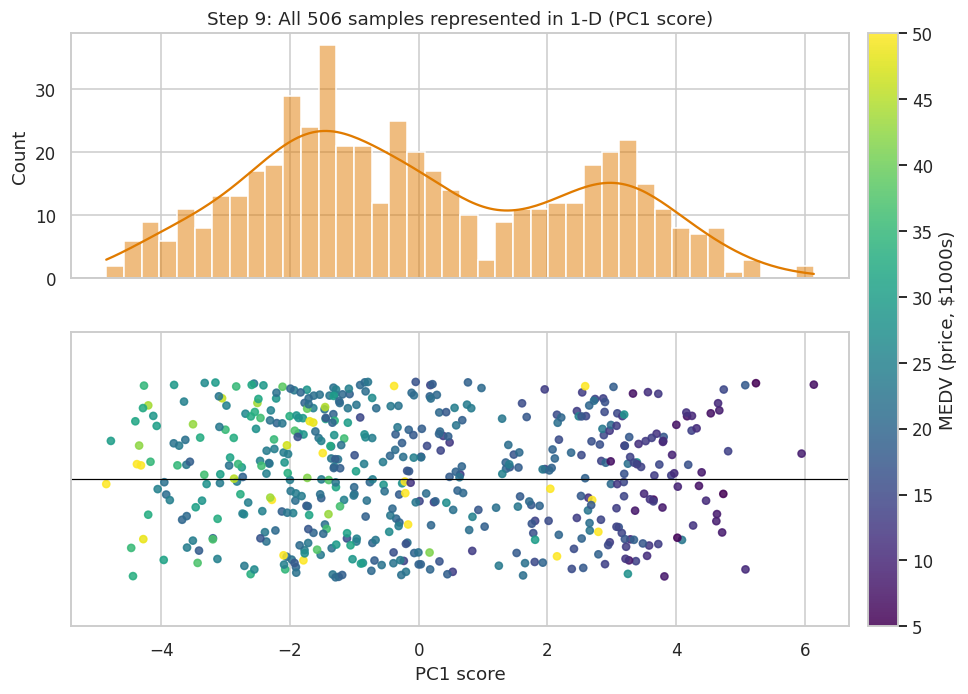

In [ ]:
print("Projected data (first 10 samples, along PC1):")
print(np.round(z[:10], 4))
print(f"\nVariance retained by PC1 alone: {explained[0]*100:.2f}%   (2 PCs: {cum_explained[1]*100:.2f}%)")

rng = np.random.default_rng(0)
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1.2]})
sns.histplot(z, bins=40, kde=True, color=ORANGE, ax=axes[0])
axes[0].set(title="Step 9: All 506 samples represented in 1-D (PC1 score)", ylabel="Count")

axes[1].axhline(0, color="black", lw=0.8)
sc = axes[1].scatter(z, rng.uniform(-0.4, 0.4, n), c=y_target, cmap="viridis", s=22, alpha=0.85)
axes[1].set(xlabel="PC1 score", yticks=[], ylim=(-0.6, 0.6))
axes[1].grid(axis="y", visible=False)
fig.colorbar(sc, ax=axes, pad=0.02).set_label(f"{TARGET} (price, $1000s)")
plt.show()

,k (PCs kept),Variance retained (%),Reconstruction MSE,Sum of dropped λ
0,1,47.1296,6.8732,6.8732
1,2,58.1548,5.4399,5.4399
2,3,67.7134,4.1973,4.1973
3,4,74.3101,3.3397,3.3397
4,5,80.7318,2.5049,2.5049
5,6,85.7888,1.8475,1.8475
6,7,89.9069,1.3121,1.3121
7,8,92.9538,0.9160,0.9160
8,9,95.0841,0.6391,0.6391
9,10,96.7783,0.4188,0.4188


✔ Reconstruction error = sum of the discarded eigenvalues.

Correlation with MEDV:  PC1 → -0.612,   PC2 → +0.286


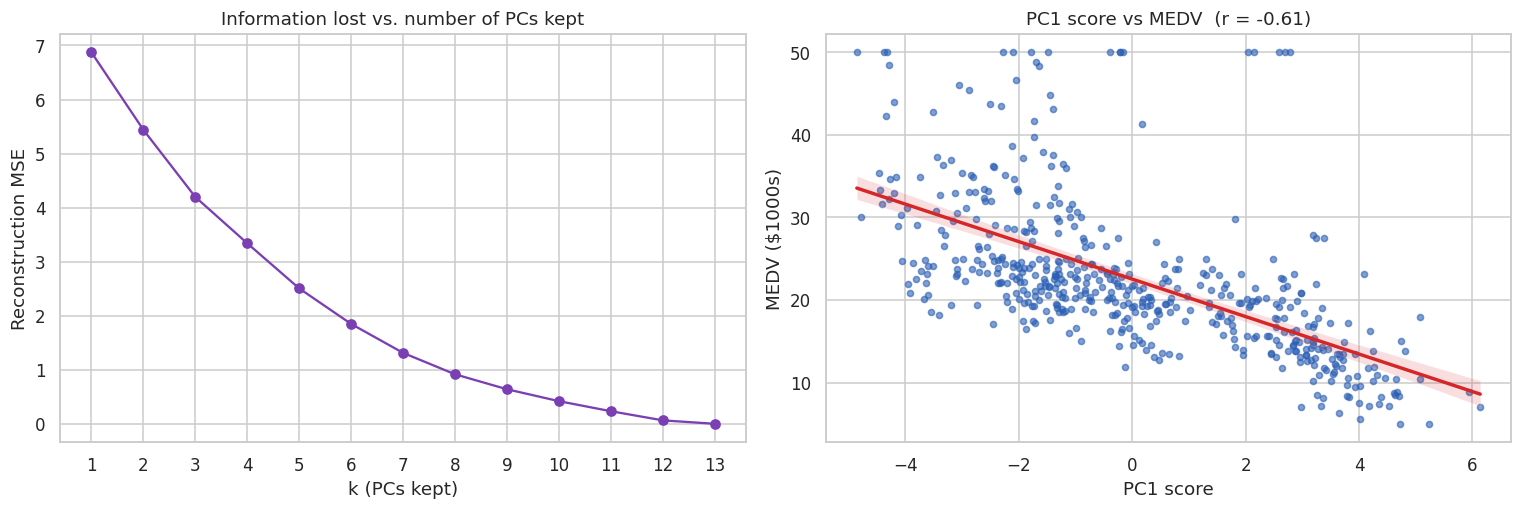

In [ ]:
# How much is lost when we keep only k components?  MSE of reconstruction Z ≈ (Z V_k) V_kᵀ
rows = []
for k in range(1, p + 1):
    Vk = eigvecs[:, :k]
    Z_hat = (Z @ Vk) @ Vk.T
    mse = np.mean(np.sum((Z - Z_hat) ** 2, axis=1))
    rows.append((k, cum_explained[k - 1] * 100, mse, eigvals[k:].sum()))
recon = pd.DataFrame(rows, columns=["k (PCs kept)", "Variance retained (%)", "Reconstruction MSE", "Sum of dropped λ"])
display(recon)
assert np.allclose(recon["Reconstruction MSE"], recon["Sum of dropped λ"])
print("✔ Reconstruction error = sum of the discarded eigenvalues.")

# Does the 1-D summary carry information about price? (price was NOT used to build PCA)
r1 = np.corrcoef(scores[:, 0], y_target)[0, 1]
r2 = np.corrcoef(scores[:, 1], y_target)[0, 1]
print(f"\nCorrelation with {TARGET}:  PC1 → {r1:+.3f},   PC2 → {r2:+.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
axes[0].plot(recon["k (PCs kept)"], recon["Reconstruction MSE"], "o-", color=PURPLE)
axes[0].set(title="Information lost vs. number of PCs kept", xlabel="k (PCs kept)",
            ylabel="Reconstruction MSE", xticks=range(1, p + 1))
sns.regplot(x=scores[:, 0], y=y_target, scatter_kws={"s": 16, "alpha": 0.6, "color": BLUE},
            line_kws={"color": RED}, ax=axes[1])
axes[1].set(title=f"PC1 score vs {TARGET}  (r = {r1:+.2f})", xlabel="PC1 score", ylabel=f"{TARGET} ($1000s)")
plt.tight_layout()
plt.show()

## Why standardize? (comparison)

The same PCA on the **centred-only** data, using the raw covariance matrix, versus the **standardized** data.

,Centred only (raw covariance),Standardized (correlation)
Explained variance (%),,
PC1,80.5823,47.1296
PC2,16.3052,11.0252
PC3,2.1349,9.5586
PC4,0.6957,6.5967
PC5,0.1300,6.4217


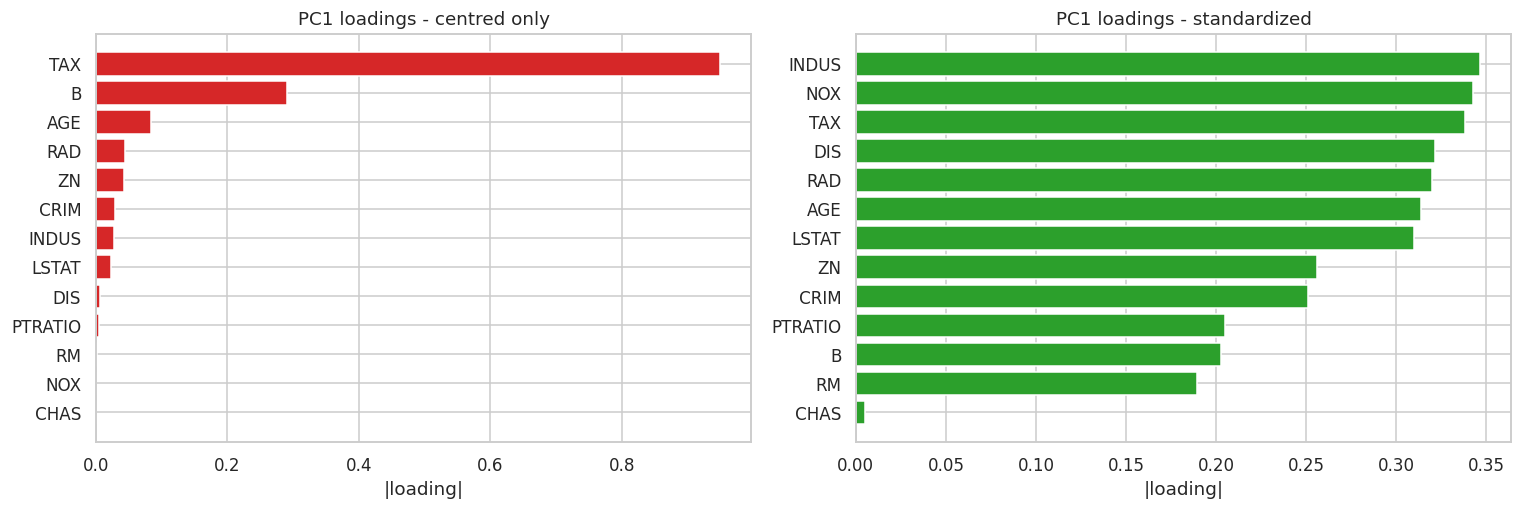

Without scaling, PC1 is essentially just TAX and B (|loadings| 0.95 and 0.29) because they have the largest raw variance,
not because they are the most informative. Standardizing lets all features compete on an equal footing.


In [ ]:
def pca_from(data):
    Cx = data.T @ data / len(data)
    w, V = np.linalg.eigh(Cx)
    o = np.argsort(w)[::-1]
    return w[o], V[:, o]

w_raw, V_raw = pca_from(X - X.mean(axis=0))
w_std, V_std = pca_from((X - X.mean(axis=0)) / X.std(axis=0))
exp_raw, exp_std = w_raw / w_raw.sum(), w_std / w_std.sum()

display(pd.DataFrame({"Centred only (raw covariance)": exp_raw[:5] * 100,
                      "Standardized (correlation)": exp_std[:5] * 100},
                     index=[f"PC{i}" for i in range(1, 6)]).rename_axis("Explained variance (%)"))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for ax, V, title, colr in [(axes[0], V_raw, "PC1 loadings - centred only", RED),
                           (axes[1], V_std, "PC1 loadings - standardized", GREEN)]:
    s = pd.Series(np.abs(V[:, 0]), index=feature_cols).sort_values()
    ax.barh(s.index, s.values, color=colr)
    ax.set(title=title, xlabel="|loading|")
plt.tight_layout()
plt.show()

top_raw = pd.Series(np.abs(V_raw[:, 0]), index=feature_cols).sort_values(ascending=False).head(2)
print(f"Without scaling, PC1 is essentially just {top_raw.index[0]} and {top_raw.index[1]} "
      f"(|loadings| {top_raw.iloc[0]:.2f} and {top_raw.iloc[1]:.2f}) because they have the largest raw variance,")
print("not because they are the most informative. Standardizing lets all features compete on an equal footing.")

## Cross-check with scikit-learn

Everything above was computed manually with NumPy. Here we confirm it with `StandardScaler` + `PCA`.
(scikit-learn divides by *n−1* in `explained_variance_`, so it equals our eigenvalues × n/(n−1); ratios and directions are identical. Signs of components may differ.)

In [ ]:
Z_sk = StandardScaler().fit_transform(X) if STANDARDIZE else X - X.mean(axis=0)
pca = PCA(n_components=p).fit(Z_sk)
scores_sk = pca.transform(Z_sk)

print("Explained variance ratio (first 5)")
print("   sklearn :", pca.explained_variance_ratio_[:5])
print("   ours    :", explained[:5])
print("\nEigenvalues (first 5)")
print("   sklearn explained_variance_ (÷n−1):", pca.explained_variance_[:5])
print("   ours × n/(n−1)                     :", (eigvals * n / (n - 1))[:5])

print("\nSame eigenvectors (up to sign)? ", np.allclose(np.abs(pca.components_), np.abs(eigvecs.T)))
print("Same PC scores (up to sign)?    ", np.allclose(np.abs(scores_sk), np.abs(scores)))

Explained variance ratio (first 5)
   sklearn : [0.4713 0.1103 0.0956 0.066  0.0642]
   ours    : [0.4713 0.1103 0.0956 0.066  0.0642]

Eigenvalues (first 5)
   sklearn explained_variance_ (÷n−1): [6.139  1.4361 1.2451 0.8593 0.8365]
   ours × n/(n−1)                     : [6.139  1.4361 1.2451 0.8593 0.8365]

Same eigenvectors (up to sign)?  True
Same PC scores (up to sign)?     True


## Summary of Results

In [ ]:
top_var = stats["Variance (population ÷n)"].idxmax()
print("=" * 70)
print(f"PCA SUMMARY  (n = {n} samples, p = {p} features, {'standardized' if STANDARDIZE else 'centred only'})")
print("=" * 70)
print(f"1. Data                 : {n} × {p} matrix (target '{TARGET}' not used)")
print(f"2. Mean / variance / std: see the statistics table (largest raw variance: {top_var} = {stats.loc[top_var, 'Variance (population ÷n)']:.1f})")
print(f"   Strongest correlation: {pairs.loc[0, 'feature 1']} vs {pairs.loc[0, 'feature 2']}  (r = {pairs.loc[0, 'r']:+.4f})")
print(f"3. Centering            : column means ≈ 0" + (", column std = 1" if STANDARDIZE else ""))
print(f"4. Covariance matrix    : {p} × {p}, trace = {np.trace(C):.4f}")
print(f"5. Eigenvalues (top 5)  : {np.round(eigvals[:5], 4).tolist()}")
print(f"   Explained variance   : PC1 = {explained[0]*100:.2f}%,  PC2 = {explained[1]*100:.2f}%,  PC3 = {explained[2]*100:.2f}%")
print(f"   Components needed    : {k_kaiser} (Kaiser), {k80} for 80%, {k90} for 90% of the variance")
top1 = loadings['PC1'].abs().sort_values(ascending=False).head(3).index
print(f"6. Eigenvectors         : PC1 loads mainly on " + ", ".join(f"{f} ({loadings.loc[f, 'PC1']:+.2f})" for f in top1))
print(f"7-8. Projection         : z = Z·v₁  (first 5 scores: {np.round(z[:5], 4).tolist()})")
print(f"9. 1-D representation   : {p} features → 1 number, retaining {explained[0]*100:.2f}% of the variance;")
print(f"                          corr(PC1, {TARGET}) = {r1:+.3f}")
print("=" * 70)
print("PCA finds a new coordinate system in which the data is most spread out,")
print("then projects the data onto the first component(s) for a lower-dimensional view.")

PCA SUMMARY  (n = 506 samples, p = 13 features, standardized)
1. Data                 : 506 × 13 matrix (target 'MEDV' not used)
2. Mean / variance / std: see the statistics table (largest raw variance: TAX = 28348.6)
   Strongest correlation: RAD vs TAX  (r = +0.9102)
3. Centering            : column means ≈ 0, column std = 1
4. Covariance matrix    : 13 × 13, trace = 13.0000
5. Eigenvalues (top 5)  : [6.1268, 1.4333, 1.2426, 0.8576, 0.8348]
   Explained variance   : PC1 = 47.13%,  PC2 = 11.03%,  PC3 = 9.56%
   Components needed    : 3 (Kaiser), 5 for 80%, 8 for 90% of the variance
6. Eigenvectors         : PC1 loads mainly on INDUS (+0.35), NOX (+0.34), TAX (+0.34)
7-8. Projection         : z = Z·v₁  (first 5 scores: [-2.0983, -1.4573, -2.0746, -2.6115, -2.4582])
9. 1-D representation   : 13 features → 1 number, retaining 47.13% of the variance;
                          corr(PC1, MEDV) = -0.612
PCA finds a new coordinate system in which the data is most spread out,
then projects the